# Spritdilemma (minimal)
Geruest fuer spaetere Anpassung an Spritpreise. We model it as follows:

Der Gewinn ist

$$
G = P - K
$$


Nun müssen wir grob schauen wie sich Preise und Kosten in den Szenarien verändern.

## Preis

Wir gehen davon aus, dass der Preis bei offenen Märkten in beiden Ländern gleich ist. 

$$
P(DE = O, PL = O) = P_{eff}
$$

Weiterhin erwarten wir, das der Preis ansteigt, wenn in einem Land Schutzmassnahmen ergriffen werden.

- Wenn in Deutschland Schutzmassnahmen, dann steigt der Preis um $a_{DE}$.
- Wenn in Polen Schutzmassnahmen, dann steigt der Preis um $a_{PL}$.
- Wenn in beiden Ländern Schutzmassnahmen ein wenig auch um den Anstieg im anderen Land

Wir haben also für Deutschland:

$$
P_{D}(DE = O, PL = O) = P_{eff}\\
P_{D}(DE = S, PL = O) = P_{eff} + a_{DE}\\
P_{D}(DE = O, PL = S) = P_{eff}\\
P_{D}(DE = S, PL = S) = P_{eff} + a_{DE} + s_{P} \cdot a_{PL}
$$

Wir haben also für Polen:

$$
P_{P}(DE = O, PL = O) = P_{eff}\\
P_{P}(DE = S, PL = O) = P_{eff}\\
P_{P}(DE = O, PL = S) = P_{eff} + a_{PL}\\
P_{P}(DE = S, PL = S) = P_{eff} + s_{P} \cdot a_{DE} + a_{PL}
$$


## Kosten

Im gleichen Sinne können wir auch die Kosten modellieren. Hier sind aber im offenen Fall realistischerweise die Kosten in Polen niedriger als in Deutschland. Weiterhin verändern sich die Kosten bei Schutzmassnahmen in Deutschland für den deutschen Spediteur nicht wirklich (sie Zölle etc.)

$$
K_{D}(DE = O, PL = O) = K_{0,D}\\
K_{D}(DE = S, PL = O) = K_{0,D}\\
K_{D}(DE = O, PL = S) = K_{0,D} + k_{PL}\\
K_{D}(DE = S, PL = S) = K_{0,D} + k_{PL} + s_{K} \cdot k_{DE}
$$

Spiegelbildlich für Polen:

$$
K_{P}(DE = O, PL = O) = K_{0,P}\\
K_{P}(DE = S, PL = O) = K_{0,P} + k_{DE}\\
K_{P}(DE = O, PL = S) = K_{0,P}\\
K_{P}(DE = S, PL = S) = K_{0,P} + s_{K} \cdot k_{DE} + k_{PL}
$$

## Gewinn

Wir können nun die Gewinne in den vier Szenarien berechnen:

$$
G_{D}(DE = O, PL = O) = P_{eff} - K_{0,D}\\
G_{D}(DE = S, PL = O) = P_{eff} + a_{DE} - K_{0,D}\\
G_{D}(DE = O, PL = S) = P_{eff} - (K_{0,D} + k_{PL})\\
G_{D}(DE = S, PL = S) = P_{eff} + a_{DE} + s_{P} \cdot a_{PL} - (K_{0,D} + k_{PL} + s_{K} \cdot k_{DE})
$$


## Erwartungswerte
Was passiert also für einen deutschen Spediteur, wenn Deutschland offen ist ? Wir nehmen an, dass Polen mit der Wahrscheinlichkeit $p_{PL}$ schliesst. Dann ist der Erwartungswert:

$$
E_{D}(DE = O) = G_{D}(DE = O, PL = S) \cdot p_{PL} + G_{D}(DE = O, PL = O) \cdot (1-p_{PL})\\
= \left[P_{eff} - (K_{0,D} + k_{PL})\right] \cdot p_{PL} + (P_{eff} - K_{0,D}) \cdot (1-p_{PL})\\
= P_{eff} - (K_{0,D} +  k_{PL}\cdot p_{PL})
$$

Jetzt der Erwartungswert, wenn Deutschland schliesst:

$$
E_{D}(DE = S) = G_{D}(DE = S, PL = S) \cdot p_{PL} + G_{D}(DE = S, PL = O) \cdot (1-p_{PL})\\
= \left[P_{eff} + a_{DE} + s_{P} \cdot a_{PL} - (K_{0,D} + k_{PL} + s_{K} \cdot k_{DE})\right] \cdot p_{PL} + (P_{eff} + a_{DE} - K_{0,D}) \cdot (1-p_{PL})\\
= (P_{eff} + a_{DE} - K_{0,D}) +\left[ s_{P} \cdot a_{PL} - k_{PL} - s_{K} \cdot k_{DE})\right] \cdot p_{PL} \\
$$

Let us now compare the two expectation values:

$$
E_{D}(DE = S) - E_{D}(DE = O) = a_{DE} +\left[ s_{P} \cdot a_{PL} - s_{K} \cdot k_{DE})\right] \cdot p_{PL}
$$

In [14]:
# O = Offen, S = Schutz
players = ['DE', 'PL']
actions = ['O', 'S']

# Sehr einfaches Gewinnmodell: Gewinn = Preis - Kosten

# erstmal eine Preissimulation
# Annahme 1: bei offenen Märken liegt der Preis in beiden Ländern gleich.
# Annahme 2: Bei beidseitigem Schutz (S,S) liegen Preise ueber (O,O).
eff_preis = 10

# anstieg bei schutz
anstieg_schutz_de = 2
anstieg_schutz_pl = 1
spillover = 0.5

price_de = {
    ("O", "O"): eff_preis,
    ("O", "S"): eff_preis,
    ("S", "O"): eff_preis + anstieg_schutz_de,
    ("S", "S"): eff_preis + anstieg_schutz_de + spillover * anstieg_schutz_pl,
}

price_pl = {
    ("O", "O"): eff_preis,
    ("O", "S"): eff_preis + anstieg_schutz_pl,
    ("S", "O"): eff_preis,
    ("S", "S"): eff_preis + anstieg_schutz_pl + spillover * anstieg_schutz_de,
}


# jetzt eine grobe Kostensimulation
eff_cost_de = 8
eff_cost_pl = 6

zoll_de = 1
zoll_pl = 1
spillover_cost = 0.5
cost_de = {
    ("O", "O"): eff_cost_de,
    ("O", "S"): eff_cost_de + zoll_pl,
    ("S", "O"): eff_cost_de,
    ("S", "S"): eff_cost_de + zoll_pl+ spillover_cost * zoll_de,
}
cost_pl = {
    ("O", "O"): eff_cost_pl,
    ("O", "S"): eff_cost_pl,
    ("S", "O"): eff_cost_pl + zoll_de,
    ("S", "S"): eff_cost_pl + zoll_de + spillover_cost * zoll_pl,
}

# payoff[(aktion_DE, aktion_PL)] = (gewinn_DE, gewinn_PL)
payoff = {
    s: (price_de[s] - cost_de[s], price_pl[s] - cost_pl[s])
    for s in [(a, b) for a in actions for b in actions]
}

def br_de(action_pl):
    return max(actions, key=lambda a: payoff[(a, action_pl)][0])

def br_pl(action_de):
    return max(actions, key=lambda b: payoff[(action_de, b)][1])

eq = [(a,b) for a in actions for b in actions if a == br_de(b) and b == br_pl(a)]
print('Payoff-Matrix (aus Gewinn = Preis - Kosten):', payoff)

Payoff-Matrix (aus Gewinn = Preis - Kosten): {('O', 'O'): (2, 4), ('O', 'S'): (1, 5), ('S', 'O'): (4, 3), ('S', 'S'): (3.0, 4.5)}


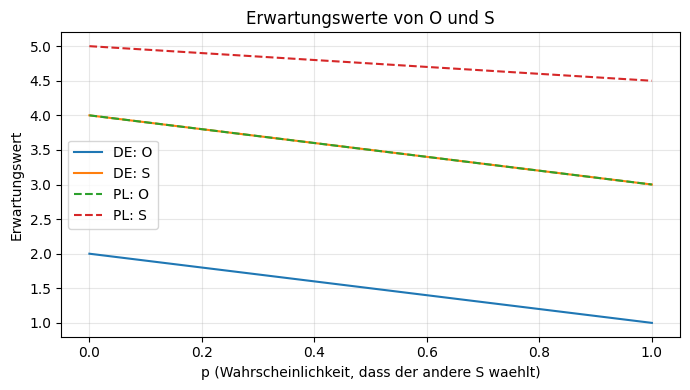

In [10]:
# Erwartungswerte bei p = Wahrscheinlichkeit, dass der andere S waehlt
import matplotlib.pyplot as plt

def ev_de(p):
    return {
        'O': (1 - p) * payoff[('O', 'O')][0] + p * payoff[('O', 'S')][0],
        'S': (1 - p) * payoff[('S', 'O')][0] + p * payoff[('S', 'S')][0],
    }

def ev_pl(p):
    return {
        'O': (1 - p) * payoff[('O', 'O')][1] + p * payoff[('S', 'O')][1],
        'S': (1 - p) * payoff[('O', 'S')][1] + p * payoff[('S', 'S')][1],
    }

ps = [i / 20 for i in range(21)]
de_o = [ev_de(p)['O'] for p in ps]
de_s = [ev_de(p)['S'] for p in ps]
pl_o = [ev_pl(p)['O'] for p in ps]
pl_s = [ev_pl(p)['S'] for p in ps]

plt.figure(figsize=(7, 4))
plt.plot(ps, de_o, label='DE: O')
plt.plot(ps, de_s, label='DE: S')
plt.plot(ps, pl_o, label='PL: O', linestyle='--')
plt.plot(ps, pl_s, label='PL: S', linestyle='--')
plt.xlabel('p (Wahrscheinlichkeit, dass der andere S waehlt)')
plt.ylabel('Erwartungswert')
plt.title('Erwartungswerte von O und S')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Gesamtgewinne je Szenario (DE + PL)
total_profit = {s: payoff[s][0] + payoff[s][1] for s in payoff}
best_total = max(total_profit, key=total_profit.get)

print('Gesamtgewinne:', total_profit)
print('Maximum gesamt:', best_total, total_profit[best_total])

Gesamtgewinne: {('O', 'O'): 6, ('O', 'S'): 6, ('S', 'O'): 7, ('S', 'S'): 7.5}
Maximum gesamt: ('S', 'S') 7.5


# Mit Nachfrage Modellierung

Im Modell oben haben wir überhaupt nicht berücksichtigt, dass die Nachfrage in den Szenarien unterschiedlich sein könnte. Hierfür machen wir den Gewinn ein wenig komplexer und zwar:

$$
G = (P-K) \cdot M
$$

Der Gewinn ist im grossen und ganzen die Marge (P-K) multipliziert mit der verkauften Menge M.